/home/sangonvi/Cefet/repositories/rionowcastdf


            timestamp  rain_pixels  rain_fraction       mean       std  \
0 2011-01-17 15:36:00          184       0.031293  31.663322  8.129971   
1 2011-01-17 15:44:00          207       0.035204  29.805325  7.576298   
2 2011-01-17 15:46:00          213       0.036224  29.541319  7.312479   
3 2011-01-17 15:48:00          197       0.033503  29.265385  7.915115   
4 2011-01-17 15:50:00          192       0.032653  29.176849  7.859232   

   maximum       volume        p50   p90        p95   p99  year  month  
0     45.0  5826.051270  30.000000  40.0  45.000000  45.0  2011      1  
1     45.0  6169.702148  30.000000  40.0  43.898239  45.0  2011      1  
2     45.0  6292.300781  30.000000  40.0  45.000000  45.0  2011      1  
3     45.0  5765.280762  30.000000  40.0  44.441284  45.0  2011      1  
4     45.0  5601.955078  28.380985  40.0  43.221180  45.0  2011      1  
       mean_reflectivity  rainfall_volume  rain_fraction    maximum
month                                            

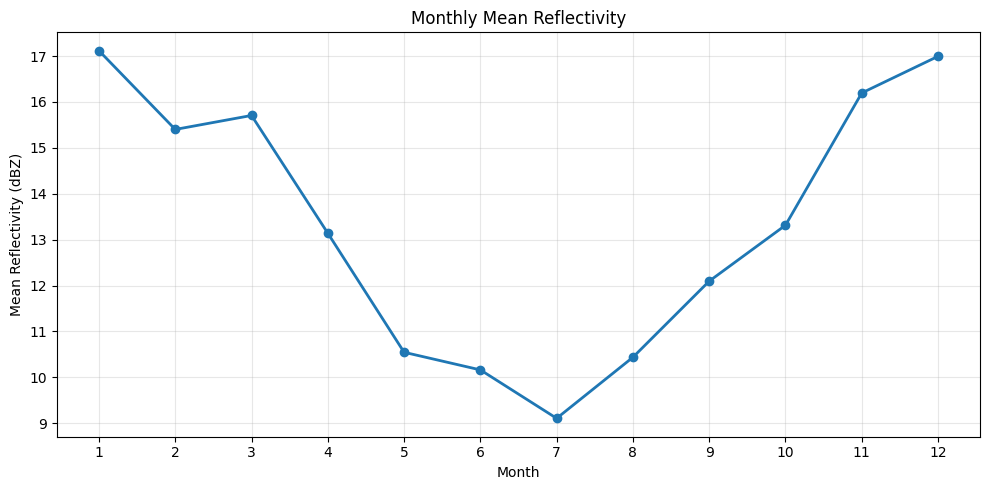

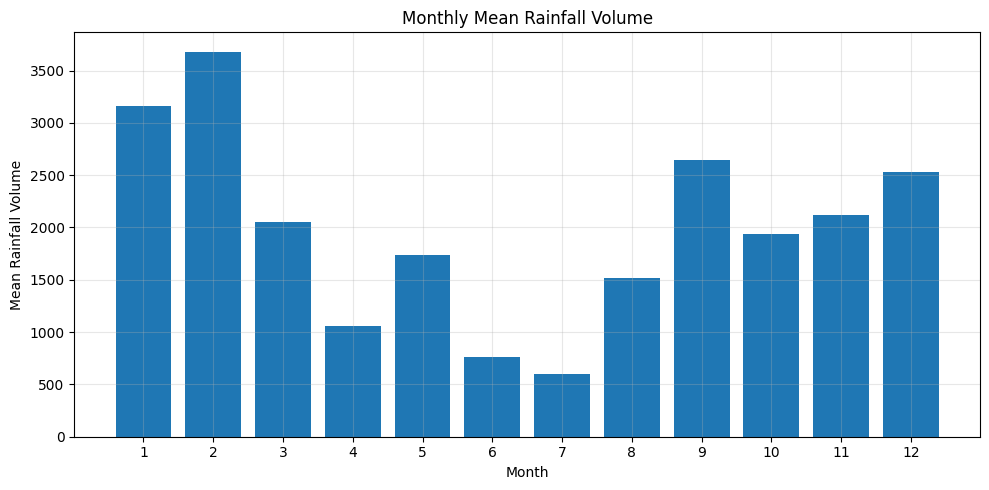

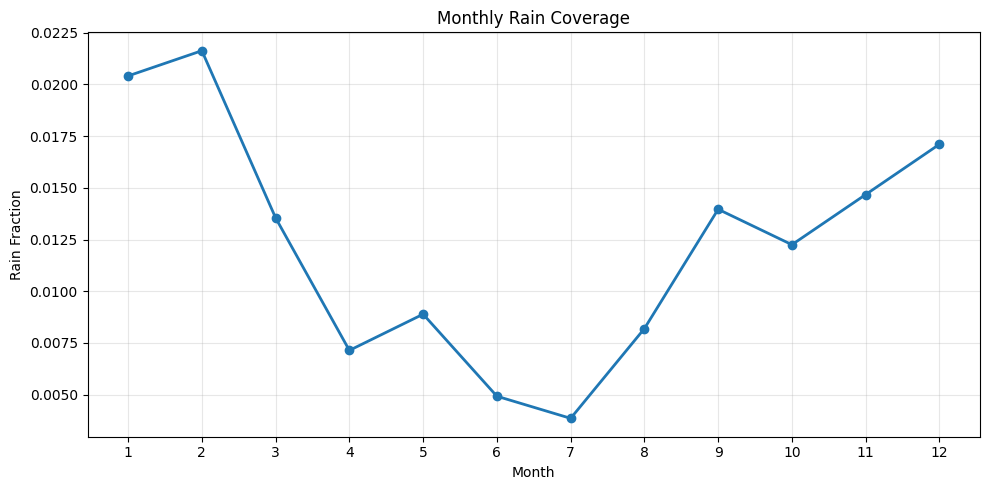

<Figure size 1400x600 with 0 Axes>

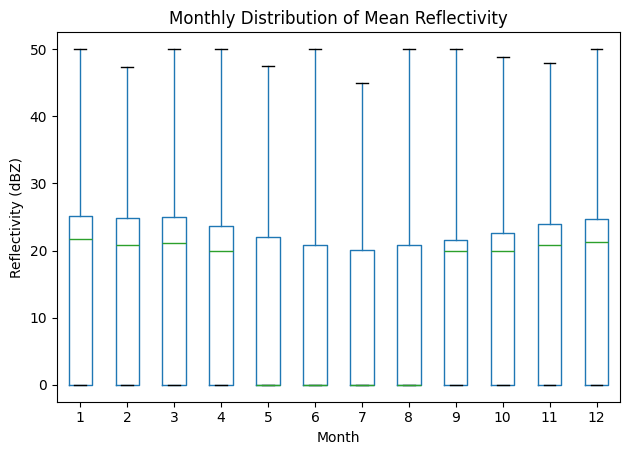


Monthly Climatology

       mean_reflectivity  rainfall_volume  rain_fraction  maximum
month                                                            
1                 17.117         3157.586          0.020   24.627
2                 15.402         3681.452          0.022   22.269
3                 15.706         2055.606          0.014   22.408
4                 13.140         1055.046          0.007   17.768
5                 10.545         1738.710          0.009   13.713
6                 10.161          762.039          0.005   12.816
7                  9.105          601.119          0.004   11.202
8                 10.436         1512.737          0.008   13.163
9                 12.095         2641.582          0.014   15.381
10                13.314         1942.534          0.012   17.715
11                16.197         2119.787          0.015   22.406
12                16.995         2532.107          0.017   24.055

Notebook completed successfully.


In [2]:
# =============================================================================
# Notebook 02
# Annual Rainfall Climatology
#
# This notebook analyses the annual climatology using the historical
# radar archive (2011-2024).
#
# Outputs
#
# figure01_monthly_mean.png
# figure02_monthly_volume.png
# figure03_monthly_rain_fraction.png
# figure04_monthly_boxplot.png
#
# =============================================================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# Configuration
# =============================================================================

STATISTICS_DIR = Path("datasets/radar_statistics")

FIGURES = Path("figures/notebook02")

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

# =============================================================================
# Load dataset
# =============================================================================

df = pd.read_parquet(
    STATISTICS_DIR / "summary.parquet"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df["year"] = df.timestamp.dt.year

df["month"] = df.timestamp.dt.month

print(df.head())

# =============================================================================
# Monthly climatology
# =============================================================================

monthly = (
    df.groupby("month")
      .agg(
          mean_reflectivity=("mean","mean"),
          rainfall_volume=("volume","mean"),
          rain_fraction=("rain_fraction","mean"),
          maximum=("maximum","mean")
      )
)

print(monthly)

# =============================================================================
# Figure 1
# Mean Reflectivity
# =============================================================================

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.mean_reflectivity,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,13))

plt.grid(alpha=0.3)

plt.xlabel("Month")

plt.ylabel("Mean Reflectivity (dBZ)")

plt.title("Monthly Mean Reflectivity")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure01_monthly_mean.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 2
# Mean Rainfall Volume
# =============================================================================

plt.figure(figsize=(10,5))

plt.bar(
    monthly.index,
    monthly.rainfall_volume
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Mean Rainfall Volume")

plt.title("Monthly Mean Rainfall Volume")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure02_monthly_volume.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 3
# Rain Fraction
# =============================================================================

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.rain_fraction,
    marker="o",
    linewidth=2
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Rain Fraction")

plt.title("Monthly Rain Coverage")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure03_monthly_rain_fraction.png",
    dpi=300
)

plt.show()

# =============================================================================
# Figure 4
# Distribution by Month
# =============================================================================

plt.figure(figsize=(14,6))

df.boxplot(
    column="mean",
    by="month",
    grid=False
)

plt.title("Monthly Distribution of Mean Reflectivity")

plt.suptitle("")

plt.xlabel("Month")

plt.ylabel("Reflectivity (dBZ)")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure04_monthly_boxplot.png",
    dpi=300
)

plt.show()

# =============================================================================
# Table
# =============================================================================

print("\nMonthly Climatology\n")

print(
    monthly.round(3)
)

monthly.to_csv(
    FIGURES/"monthly_climatology.csv"
)

print("\nNotebook completed successfully.")